In [53]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAXResults

# Load the saved SARIMAX model results
model = SARIMAXResults.load('SARIMAX.pkl')




In [54]:
# Set TensorFlow threading optimizations before importing it
os.environ["TF_INTER_OP_PARALLELISM_THREADS"] = "4"
os.environ["TF_INTRA_OP_PARALLELISM_THREADS"] = "4"

# Load Data
df = pd.read_csv('dataset/Walmart.csv')

In [55]:
# Convert date columns to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

df.head()

# Group by Date and aggregate (e.g., sum for Weekly_Sales)
df = df.groupby('Date').agg({
  'Weekly_Sales': 'sum',
  'Holiday_Flag': 'max',
  'Temperature': 'mean',
  'Fuel_Price': 'mean',
  'CPI': 'mean',
  'Unemployment': 'mean'
}).reset_index()

df.head()

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,2010-02-05,49750740.50,0,34.037333,2.717844,167.730885,8.619311
1,2010-02-12,48336677.63,1,34.151333,2.694022,167.825608,8.619311
2,2010-02-19,48276993.78,0,37.719778,2.672067,167.871686,8.619311
3,2010-02-26,43968571.13,0,39.243556,2.683933,167.909657,8.619311
4,2010-03-05,46871470.30,0,42.917333,2.731200,167.947628,8.619311


In [57]:
features = df.drop('Weekly_Sales', axis=1)
target = df['Weekly_Sales']

In [58]:
exog = features[['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']]
sarimax_model = SARIMAXResults.load('SARIMAX.pkl')
nobs = sarimax_model.nobs
features['SARIMAX'] = sarimax_model.predict(start=0, end=nobs-1, exog=exog)

In [59]:
features.head()

,Date,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,SARIMAX
0,2010-02-05,0,34.037333,2.717844,167.730885,8.619311,4.832606e+07
1,2010-02-12,1,34.151333,2.694022,167.825608,8.619311,5.256246e+07
2,2010-02-19,0,37.719778,2.672067,167.871686,8.619311,4.752636e+07
3,2010-02-26,0,39.243556,2.683933,167.909657,8.619311,4.891669e+07
4,2010-03-05,0,42.917333,2.731200,167.947628,8.619311,4.799678e+07


In [60]:
target

0      49750740.50
1      48336677.63
2      48276993.78
3      43968571.13
4      46871470.30
          ...     
138    43734899.40
139    47566639.31
140    46128514.25
141    45122410.57
142    45544116.29
Name: Weekly_Sales, Length: 143, dtype: float64

In [63]:
# standardization
features['Date'] = df['Date'].astype(np.int64) // 10**9
features_scaled = np.log1p(features)
target_scaled = np.log1p(target)

In [68]:
features_scaled.head()

,Date,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,SARIMAX
0,20.958597,0.000000,3.556414,1.313144,5.128305,2.263773,17.693482
1,20.959075,0.693147,3.559663,1.306716,5.128866,2.263773,17.777513
2,20.959553,0.000000,3.656351,1.300755,5.129139,2.263773,17.676795
3,20.960030,0.000000,3.694950,1.303981,5.129364,2.263773,17.705629
4,20.960507,0.000000,3.782309,1.316730,5.129589,2.263773,17.686644


In [69]:
features_scaled.isna().sum().sum()

np.int64(0)

In [67]:
target_scaled.head()

0    17.722536
1    17.693701
2    17.692466
3    17.598986
4    17.662920
Name: Weekly_Sales, dtype: float64

In [70]:
target_scaled.isna().sum()

np.int64(0)

In [84]:
train_dataset = tf.data.Dataset.from_tensor_slices((features_scaled, target_scaled))

train_dataset = train_dataset.batch(8).prefetch(tf.data.experimental.AUTOTUNE)

# Enable Mixed Precision Training for Speed-up (Only if GPU Available)
tf.keras.mixed_precision.set_global_policy('float32')

# Enable XLA Compilation for Faster Computation
tf.config.optimizer.set_jit(True)

# Neural Network Model (Optimized)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(features_scaled.shape[1],)),  # Explicit Input layer

    tf.keras.layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.ReLU(),

    tf.keras.layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.ReLU(),

    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.ReLU(),

    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.ReLU(),

    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.ReLU(),

    tf.keras.layers.Dense(1)
])


In [87]:
# Compile Model with Adjusted Learning Rate
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])

# Early Stopping
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train Model with validation dataset
history = model.fit(train_dataset, epochs=300, verbose=1)

Epoch 1/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 148.5673 - mae: 11.6117
Epoch 2/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 147.5699 - mae: 11.7500
Epoch 3/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 144.2552 - mae: 11.5784
Epoch 4/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 148.4515 - mae: 11.7879
Epoch 5/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 142.7581 - mae: 11.4716
Epoch 6/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step - loss: 139.5259 - mae: 11.4120
Epoch 7/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 140.8723 - mae: 11.4035
Epoch 8/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step - loss: 139.0355 - mae: 11.3142
Epoch 9/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step - loss: 137.2731 - mae: 11.2820
Epoch 10/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 130.4289 - mae: 10.9303
Epoch 11/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 135.4509 - mae: 11.1633
Epoch 12/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 132.4832 - mae: 11.

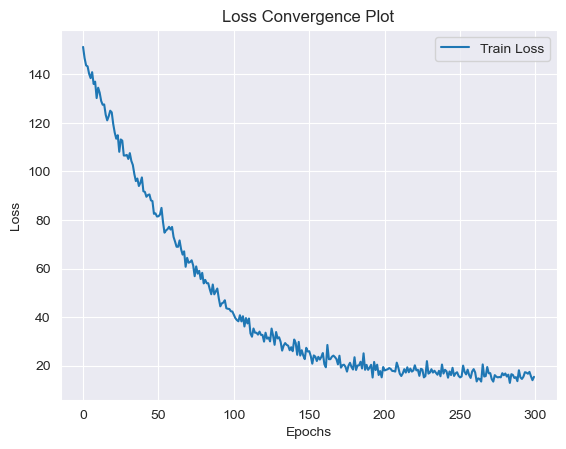

In [88]:
# Plot Training Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Loss Convergence Plot")
plt.show()# Compile Model with Adjusted Learning Rate

In [89]:
predictions = model.predict(features_scaled)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [90]:
predictions

array([[49.83353 ],
       [54.80097 ],
       [41.979313],
       [41.126408],
       [32.230747],
       [18.023619],
       [16.81691 ],
       [16.203796],
       [15.403596],
       [18.50533 ],
       [16.016804],
       [16.819147],
       [16.721584],
       [16.900486],
       [17.847488],
       [17.789555],
       [19.049566],
       [21.765396],
       [22.277931],
       [22.130539],
       [24.96158 ],
       [23.506756],
       [25.259249],
       [26.180391],
       [27.919115],
       [25.650646],
       [25.614273],
       [25.066343],
       [25.472187],
       [23.849693],
       [23.225025],
       [45.46036 ],
       [20.770111],
       [20.89827 ],
       [20.857704],
       [21.668789],
       [20.294727],
       [17.943745],
       [17.343468],
       [13.356967],
       [13.978852],
       [14.342973],
       [26.922247],
       [34.24943 ],
       [36.946873],
       [30.671978],
       [40.50119 ],
       [47.01089 ],
       [39.38902 ],
       [63.128708],


In [91]:
target_scaled

0      17.722536
1      17.693701
2      17.692466
3      17.598986
4      17.662920
         ...    
138    17.593657
139    17.677642
140    17.646942
141    17.624890
142    17.634192
Name: Weekly_Sales, Length: 143, dtype: float64

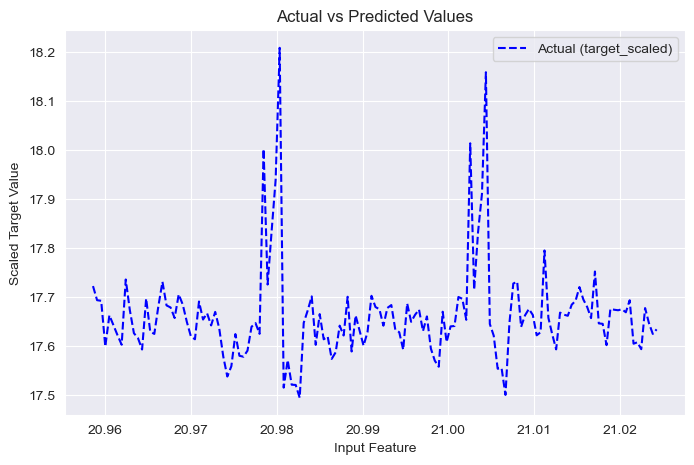

In [97]:
# Plot actual vs. predicted values
plt.figure(figsize=(8, 5))
plt.plot(features_scaled['Date'], target_scaled, label="Actual (target_scaled)", color="blue", linestyle="dashed")
plt.xlabel("Input Feature")
plt.ylabel("Scaled Target Value")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.show()

In [100]:
# Residual Plot
residuals = target_scaled - predictions
plt.figure(figsize=(8, 6))
plt.scatter(target_scaled, residuals, color='purple')
plt.axhline(y=0, color='red', linestyle="--", label="Zero Error")
plt.xlabel("Actual Weekly Sales")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot: Predictions vs Actual Values")
plt.legend()
plt.grid(True)
plt.show()

ValueError: Data must be 1-dimensional, got ndarray of shape (143, 143) instead

In [104]:
type(target_scaled)

pandas.core.series.Series

In [103]:
type(predictions)

numpy.ndarray

In [105]:
predictions.shape

(143, 1)